# Anomaly detection using Isolation Forest

Current code will likely catch a big surge in the closing price—such as the one for BANANAS31/USDC on June 21st at around 16:00—as an anomaly.

Here's why:

IsolationForest is designed to detect outliers in the data, and a sudden, significant price surge will appear as an outlier compared to the surrounding values.
The code uses the closing price as the feature for anomaly detection, so any large, abrupt change (up or down) in the close price will be flagged as an anomaly.
After running the code, you can check the printed anomalies and the plot: red 'x' markers will indicate detected anomalies. If the surge at 16:00 on June 21st is much higher than the previous and following prices, it should be marked as an anomaly.

In [1]:
%pip install scikit-learn matplotlib requests pandas


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Number of anomalies detected: 15
                        close
open_time                    
2025-06-21 05:00:00  0.005283
2025-06-21 06:00:00  0.005298
2025-06-21 09:00:00  0.005365
2025-06-21 10:00:00  0.005339
2025-06-22 09:00:00  0.007042
2025-06-22 10:00:00  0.007128
2025-06-22 11:00:00  0.007316
2025-06-22 12:00:00  0.007243
2025-06-22 15:00:00  0.007211
2025-06-22 16:00:00  0.007248
2025-06-22 17:00:00  0.007464
2025-06-22 18:00:00  0.007409
2025-06-22 19:00:00  0.007488
2025-06-22 20:00:00  0.007393
2025-06-22 21:00:00  0.007408


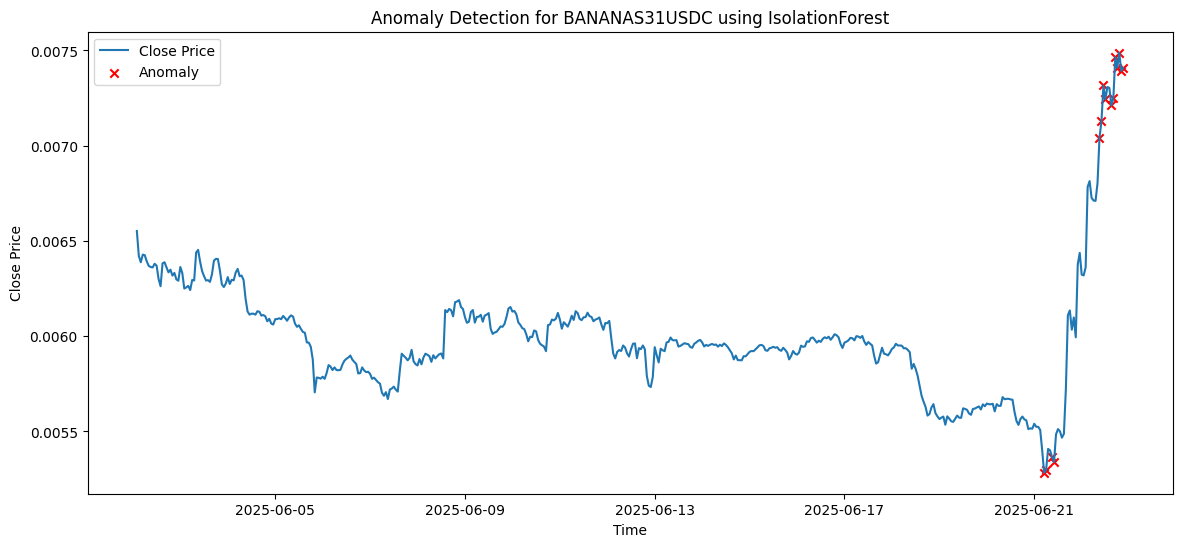

In [2]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import requests
import matplotlib.pyplot as plt

# Parameters
symbol = 'BANANAS31USDC'
interval = '1h'
limit = 500

# Fetch klines from Binance API
url = f'https://api.binance.com/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}'
response = requests.get(url)
data = response.json()

# Prepare DataFrame
df = pd.DataFrame(data, columns=[
    'open_time', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_asset_volume', 'number_of_trades',
    'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore'
])

# Convert types
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = df[col].astype(float)
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
df.set_index('open_time', inplace=True)

# Use closing price for anomaly detection
X = df[['close']].values

# Fit IsolationForest
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X)

# -1 indicates anomaly, 1 indicates normal
anomalies = df[df['anomaly'] == -1]
print(f"Number of anomalies detected: {len(anomalies)}")
print(anomalies[['close']])

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['close'], label='Close Price')
plt.scatter(anomalies.index, anomalies['close'], color='red', label='Anomaly', marker='x')
plt.title(f'Anomaly Detection for {symbol} using IsolationForest')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()
